# Coral thermal stress and coastal livelihoods

**Climate & Health · Lesson 08 · 20–35 minutes**

[Run this lesson in Python Lab](https://jltobias.github.io/JupyterLite-Climate-and-Health/lite/lab/index.html?path=notebooks/08_coral_bleaching.ipynb)

Calculate a teaching analogue of NOAA Coral Reef Watch Degree Heating Weeks (DHW). For this exercise, a daily HotSpot is SST minus a specified maximum monthly mean. Only HotSpots ≥1 °C contribute; sum the previous 84 daily values and divide by 7.

**Learning goal:** Run the analysis, explain its units and assumptions, then adapt the exercise.

Data labels: **observed NASA** appears in lesson 01. Fictional facility scenarios, local temperatures, costs, flows and modeled impacts are **synthetic teaching data**. The separate **archived Healthsites / OpenStreetMap points** are actual public map records with unverified current services; no synthetic impacts or funding claims apply to them.

In [1]:
from pathlib import Path
import sys, json, statistics
root = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "healthlab.py").exists()), None)
if root is None:
    raise RuntimeError("Open this notebook inside the bundled content folder; healthlab.py and data/ are required.")
if str(root) not in sys.path: sys.path.insert(0, str(root))
import healthlab as h
from IPython.display import display, SVG
cases = h.cases()
print("Loaded", len(cases), "fictional facility scenarios; city coordinates are context only.")

Loaded 7 fictional facility scenarios; city coordinates are context only.


## Analysis 1

Run this cell, then inspect the units and result before continuing.

In [2]:
hotspots = [0.5]*28 + [1.0]*28 + [2.0]*28
dhw=h.degree_heating_weeks(hotspots)
print("Synthetic 84-day DHW:",dhw,"°C-weeks")
assert dhw == 12
print("After replacing 28 days at 2 °C with 0.9 °C:",h.degree_heating_weeks(hotspots[:56]+[0.9]*28))

Synthetic 84-day DHW: 12.0 °C-weeks
After replacing 28 days at 2 °C with 0.9 °C: 4.0


## Analysis 2

Run this cell, then inspect the units and result before continuing.

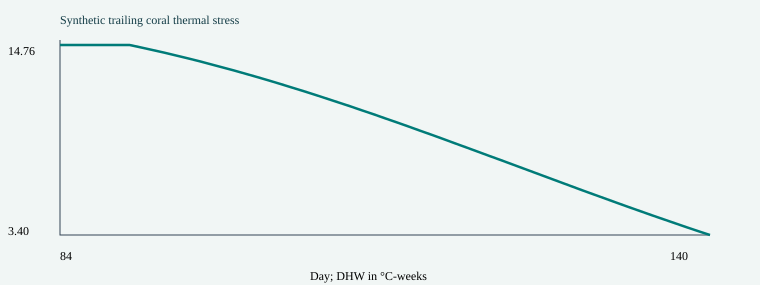

In [3]:
series=[max(0,0.8+1.0*__import__("math").sin(i/25)) for i in range(140)]
rolling=[h.degree_heating_weeks(series[i-83:i+1]) for i in range(83,len(series))]
display(SVG(h.line_svg(list(range(84,141)),rolling,"Synthetic trailing coral thermal stress","Day; DHW in °C-weeks")))

## Interpretation

This is a method exercise, not a NOAA operational product or reef assessment. Bleaching and recovery depend on species, acclimatization and local pressures. Nature-based coastal protection also depends on ecosystem condition; invented DHW cannot quantify health impacts.

## Your exercise

Replace 1.0 with 0.99 °C and explain the discontinuity. Why can a high DHW indicate accumulated thermal stress without establishing observed bleaching? Trace a possible reef → fisheries/tourism → household income → food/service-access pathway, identifying evidence needed at each step.

## Worked reasoning check

Before trusting a changed result, identify the input you changed, predict the direction, and compare with the printed baseline. Explain any threshold or missing-data behavior; a valid calculation alone does not validate a real-world claim.

## Source and limitation

NOAA CRW methodology: https://coralreefwatch.noaa.gov/product/5km/methodology.php ; citation guidance: https://coralreefwatch.noaa.gov/satellite/docs/recommendations_crw_citation.php . No NOAA satellite values or figures distributed.

Original educational text: CC BY 4.0, James L. Tobias and contributors. Original synthetic fixtures: CC0. Original calculation code: MIT.